# Pipeline Validation Graphs

Runs the full **Detection → Tracking → Action Recognition** pipeline on multiple datasets and generates charts to demonstrate that the model predicts the correct action class on images from known behavior folders.

| Dataset | True class | Source |
|---------|-----------|--------|
| `fanning` | fanning | AR_dataset/fanning/train + val |
| `trophallaxis` | trophallaxis | AR_dataset/trophallaxis/train + val |
| `det_data` | unlabeled | DET_data_OG/images |

> **Read-only on source folders.** This notebook never writes to the data directories.

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict, deque
import cv2
from transformers import AutoModel
from torchvision import transforms
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import supervision as sv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp.autocast_mode import autocast
from datetime import datetime

print(f'supervision: {sv.__version__}')
print('Imports OK')

supervision: 0.27.0.post1
Imports OK


## Configuration

In [ ]:
BASE_DIR = 'D:/Projects/Masters'

# Model paths
YOLO_PATH     = os.path.join(BASE_DIR, 'Trained_Models/DET_medium-best.pt')
TEMPORAL_PATH = os.path.join(BASE_DIR, 'ActionRecognition/best_temporal_buf8.pt')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'ActionRecognition')

# Detection
DET_CONF     = 0.55
SAHI_SLICE   = 640
SAHI_OVERLAP = 0.35
CROP_PAD     = 0.35

# Tracking
TRACK_BUFFER = 30
FPS          = 30

# Action recognition
BUFFER_SIZE    = 16
MIN_BUFFER     = 4
ACTION_CONF_TH = 0.55
ACTION_CLASSES = ['fanning', 'neutral', 'trophallaxis']

# ── Limit frames per dataset ─────────────────────────────────────────────────
# 500 for a quick test run (~a few minutes). Set to None to process all images.
MAX_FRAMES_PER_DATASET = 1000

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device                 : {device}')
print(f'Max frames per dataset : {MAX_FRAMES_PER_DATASET}')

Device                 : cuda
Max frames per dataset : 1000


## Model Definition
Must be identical to the training definition.

In [3]:
class TemporalSequenceClassifier(nn.Module):
    def __init__(self, feature_dim=384, num_classes=3, num_heads=4,
                 num_layers=2, dropout=0.3, max_seq_len=33):
        super().__init__()
        self.cls_token   = nn.Parameter(torch.randn(1, 1, feature_dim) * 0.02)
        self.pos_embed   = nn.Embedding(max_seq_len, feature_dim)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=feature_dim, nhead=num_heads,
            dim_feedforward=feature_dim * 2,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(feature_dim)
        self.classifier  = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )

    def forward(self, x, padding_mask=None):
        B, T, _ = x.shape
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0)
        x   = x + self.pos_embed(pos)
        if padding_mask is not None:
            cls_mask     = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        return self.classifier(self.norm(x[:, 0]))

## Load Models

In [4]:
yolo_model = YOLO(YOLO_PATH)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model=yolo_model,
    confidence_threshold=DET_CONF,
    device=str(device),
)
print('YOLO + SAHI loaded')

dinov2 = AutoModel.from_pretrained('facebook/dinov2-small').to(device)
dinov2.eval()
for p in dinov2.parameters():
    p.requires_grad = False
print('DINOv2 loaded (frozen)')

ckpt = torch.load(TEMPORAL_PATH, map_location=device)
cfg  = ckpt['config']
temporal_model = TemporalSequenceClassifier(
    feature_dim=cfg['feature_dim'],
    num_classes=cfg['num_classes'],
    num_heads=cfg['num_heads'],
    num_layers=cfg['num_layers'],
    dropout=cfg['dropout'],
    max_seq_len=cfg['buffer_size'] + 1,
).to(device)
temporal_model.load_state_dict(ckpt['model_state'])
temporal_model.eval()
BUFFER_SIZE = cfg['buffer_size']   # sync with loaded model — overrides config cell
print(f"Temporal model loaded — epoch {ckpt['epoch']}, Val F1: {ckpt['val_f1']:.4f}")
print(f"Buffer size: {BUFFER_SIZE} frames")

YOLO + SAHI loaded
DINOv2 loaded (frozen)
Temporal model loaded — epoch 14, Val F1: 0.9703
Buffer size: 8 frames


## Helper Functions

In [5]:
_preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_crop(frame, xyxy, pad=CROP_PAD):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = map(int, xyxy)
    px = int((x2 - x1) * pad)
    py = int((y2 - y1) * pad)
    x1 = max(0, x1 - px);  y1 = max(0, y1 - py)
    x2 = min(w, x2 + px);  y2 = min(h, y2 + py)
    crop = frame[y1:y2, x1:x2]
    return crop if crop.size > 0 else None


def get_dinov2_feature(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    tensor   = _preprocess(crop_rgb).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(str(device)):
        out = dinov2(tensor)
        cls = out.last_hidden_state[:, 0]
    return cls.squeeze(0)


def classify_buffer(feature_list):
    T = BUFFER_SIZE
    N = len(feature_list)
    feats, mask = [], []
    for i in range(T):
        if i < N:
            feats.append(feature_list[i]);  mask.append(False)
        else:
            feats.append(feature_list[-1]); mask.append(True)
    x     = torch.stack(feats).unsqueeze(0).to(device)
    pmask = torch.tensor(mask, dtype=torch.bool).unsqueeze(0).to(device)
    with torch.no_grad(), autocast(str(device)):
        logits = temporal_model(x, padding_mask=pmask)
        probs  = torch.softmax(logits, dim=1)
    conf, idx = probs.max(dim=1)
    conf  = conf.item()
    label = ACTION_CLASSES[idx.item()] if conf >= ACTION_CONF_TH else 'uncertain'
    return label, conf


print('Helpers ready')

Helpers ready


## Dataset Discovery

In [6]:
AR_ROOT  = os.path.join(BASE_DIR, 'Data/AR_dataset')
DET_ROOT = os.path.join(BASE_DIR, 'Data/DET_data_OG')


def collect_images(folder):
    exts = ('.jpg', '.jpeg', '.png')
    return sorted([
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ])


datasets = {}

# AR dataset: each action class, all splits combined
for cls in ['fanning', 'trophallaxis']:
    paths = []
    for split in ['train', 'val']:
        folder = os.path.join(AR_ROOT, cls, split, 'images')
        if os.path.isdir(folder):
            paths.extend(collect_images(folder))
    datasets[cls] = sorted(paths)

# DET data (unlabeled — detection reference)
det_folder = os.path.join(DET_ROOT, 'images')
if os.path.isdir(det_folder):
    datasets['det_data'] = collect_images(det_folder)

print('Dataset summary:')
for name, imgs in datasets.items():
    limit_note = f'  →  using first {MAX_FRAMES_PER_DATASET}' if MAX_FRAMES_PER_DATASET else ''
    print(f'  {name:20s}: {len(imgs):,} images{limit_note}')

Dataset summary:
  fanning             : 18,000 images  →  using first 1000
  trophallaxis        : 20,480 images  →  using first 1000
  det_data            : 6,200 images  →  using first 1000


## Per-Dataset Inference

Processes each dataset independently with a fresh tracker and buffers.
No display window — pure batch collection.

In [7]:
all_results = []

for dataset_name, image_paths in datasets.items():
    paths_to_run = image_paths[:MAX_FRAMES_PER_DATASET] if MAX_FRAMES_PER_DATASET else image_paths
    print(f"\n{'='*60}")
    print(f"Dataset : {dataset_name}  ({len(paths_to_run):,} frames)")

    # Fresh tracker + buffers for each dataset
    try:
        tracker = sv.ByteTrack(
            track_activation_threshold=0.45,
            lost_track_buffer=TRACK_BUFFER,
            minimum_matching_threshold=0.8,
            frame_rate=FPS,
        )
    except TypeError:
        tracker = sv.ByteTrack()

    track_buffers = defaultdict(lambda: deque(maxlen=BUFFER_SIZE))
    track_actions = {}
    n_before = len(all_results)

    for frame_idx, img_path in enumerate(paths_to_run):
        if frame_idx % 100 == 0:
            print(f'  frame {frame_idx}/{len(paths_to_run)}', flush=True)

        frame = cv2.imread(img_path)
        if frame is None:
            continue

        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=SAHI_SLICE, slice_width=SAHI_SLICE,
            overlap_height_ratio=SAHI_OVERLAP, overlap_width_ratio=SAHI_OVERLAP,
            verbose=0,
        )
        if not result.object_prediction_list:
            continue

        boxes     = np.array([p.bbox.to_xyxy() for p in result.object_prediction_list])
        det_confs = np.array([p.score.value    for p in result.object_prediction_list])
        class_ids = np.array([p.category.id    for p in result.object_prediction_list])

        detections = sv.Detections(xyxy=boxes, confidence=det_confs, class_id=class_ids)
        detections = tracker.update_with_detections(detections)

        if detections.tracker_id is None or len(detections) == 0:
            continue

        for i, track_id in enumerate(detections.tracker_id):
            xyxy     = detections.xyxy[i]
            det_conf = float(detections.confidence[i])

            crop = extract_crop(frame, xyxy)
            if crop is not None:
                feat = get_dinov2_feature(crop)
                track_buffers[track_id].append(feat)

            buf_size = len(track_buffers[track_id])

            if buf_size >= MIN_BUFFER:
                action, conf = classify_buffer(list(track_buffers[track_id]))
                track_actions[track_id] = (action, conf)
            elif track_id in track_actions:
                action, conf = track_actions[track_id]
            else:
                action, conf = 'buffering', 0.0

            all_results.append({
                'dataset'    : dataset_name,
                'frame_idx'  : frame_idx,
                'img_name'   : os.path.basename(img_path),
                'track_id'   : int(track_id),
                'action'     : action,
                'action_conf': conf,
                'det_conf'   : det_conf,
                'buf_size'   : buf_size,
            })

    added = len(all_results) - n_before
    print(f'  Done — {added:,} detections logged')

df = pd.DataFrame(all_results)
ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = os.path.join(OUTPUT_DIR, f'graph_results_{ts}.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(f'Total rows: {len(df):,}')
print(df.groupby(['dataset', 'action']).size().to_string())


Dataset : fanning  (1,000 frames)
  frame 0/1000
  frame 100/1000
  frame 200/1000
  frame 300/1000
  frame 400/1000
  frame 500/1000
  frame 600/1000
  frame 700/1000
  frame 800/1000
  frame 900/1000
  Done — 8,212 detections logged

Dataset : trophallaxis  (1,000 frames)
  frame 0/1000
  frame 100/1000
  frame 200/1000
  frame 300/1000
  frame 400/1000
  frame 500/1000
  frame 600/1000
  frame 700/1000
  frame 800/1000
  frame 900/1000
  Done — 25,659 detections logged

Dataset : det_data  (1,000 frames)
  frame 0/1000
  frame 100/1000
  frame 200/1000
  frame 300/1000
  frame 400/1000
  frame 500/1000
  frame 600/1000
  frame 700/1000
  frame 800/1000
  frame 900/1000
  Done — 1,330 detections logged

Saved: D:/Projects/Masters\ActionRecognition\graph_results_20260503_030748.csv
Total rows: 35,201
dataset       action      
det_data      buffering         466
              fanning           261
              neutral           580
              uncertain          23
fanning       b

## Graphs

All figures are saved to `ActionRecognition/`.
Run cells below after the inference loop completes (or reload a saved CSV).

In [8]:
# ── Optional: reload from a saved CSV instead of re-running inference ─────────
# csv_path = 'D:/Projects/Masters/ActionRecognition/graph_results_XXXXXXXX_XXXXXX.csv'
# df = pd.read_csv(csv_path)
# print(f'Loaded {len(df):,} rows from {csv_path}')

ACTION_COLORS_HEX = {
    'fanning'     : '#00dc64',
    'trophallaxis': '#ff7800',
    'neutral'     : '#64b4ff',
    'uncertain'   : '#dc0000',
    'buffering'   : '#aaaaaa',
}

sns.set_theme(style='whitegrid', font_scale=1.05)
print('Ready to plot')

Ready to plot


### Figure 1 — Pseudo-Confusion Matrix

Rows = input dataset (known true class).  
Columns = model-predicted action.  
A strong diagonal proves the model predicts the correct class on known-class images.

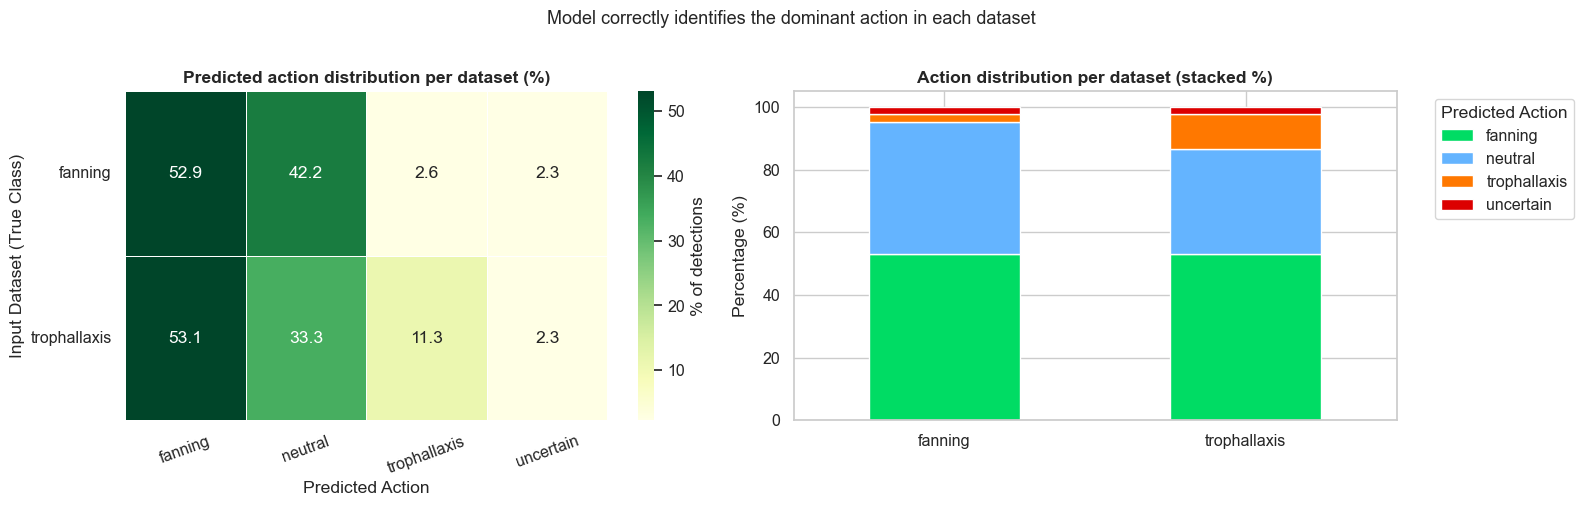

Saved: D:/Projects/Masters\ActionRecognition\graph_1_confusion.png


In [9]:
# Use only the two labeled AR datasets for correctness analysis
ar_df = df[df['dataset'].isin(['fanning', 'trophallaxis'])].copy()
classified = ar_df[ar_df['action'] != 'buffering']

# Percentage breakdown: what % of detections in each dataset get each action label
pivot = classified.groupby(['dataset', 'action']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: heatmap
sns.heatmap(
    pivot_pct, annot=True, fmt='.1f', cmap='YlGn',
    ax=axes[0], cbar_kws={'label': '% of detections'},
    linewidths=0.5, linecolor='white',
)
axes[0].set_title('Predicted action distribution per dataset (%)', fontweight='bold')
axes[0].set_xlabel('Predicted Action')
axes[0].set_ylabel('Input Dataset (True Class)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', rotation=0)

# Right: stacked bar
bar_colors = [ACTION_COLORS_HEX.get(c, '#888888') for c in pivot_pct.columns]
pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('Action distribution per dataset (stacked %)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Predicted Action', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_ylim(0, 105)

plt.suptitle('Model correctly identifies the dominant action in each dataset',
             fontsize=13, y=1.01)
plt.tight_layout()
out1 = os.path.join(OUTPUT_DIR, 'graph_1_confusion.png')
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

### Figure 2 — Detection Confidence per Dataset

Shows YOLO detection confidence across all three data sources.  
Confirms the detector generalises beyond its own training data.


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



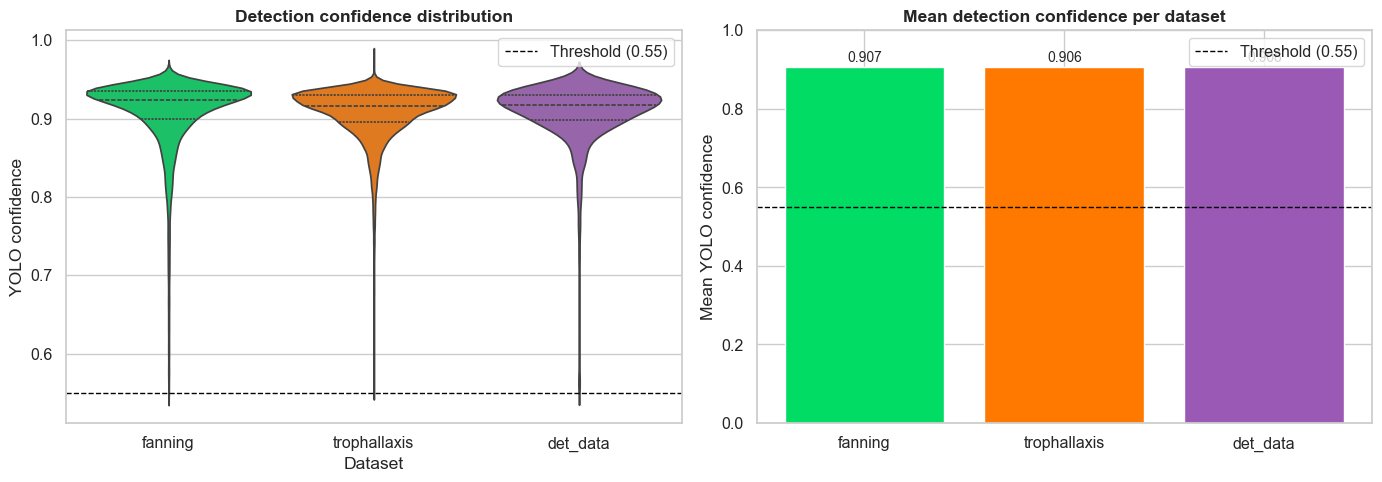

Saved: D:/Projects/Masters\ActionRecognition\graph_2_det_confidence.png


In [10]:
DATASET_COLORS = {
    'fanning'     : '#00dc64',
    'trophallaxis': '#ff7800',
    'det_data'    : '#9b59b6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violin plot
order = [d for d in ['fanning', 'trophallaxis', 'det_data'] if d in df['dataset'].unique()]
palette = {d: DATASET_COLORS[d] for d in order}
sns.violinplot(
    data=df, x='dataset', y='det_conf', order=order,
    palette=palette, inner='quartile', ax=axes[0]
)
axes[0].axhline(DET_CONF, color='black', linestyle='--', linewidth=1,
                label=f'Threshold ({DET_CONF})')
axes[0].set_title('Detection confidence distribution', fontweight='bold')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('YOLO confidence')
axes[0].legend()

# Right: mean detection confidence bar
mean_conf = df.groupby('dataset')['det_conf'].mean().reindex(order)
bars = axes[1].bar(
    mean_conf.index, mean_conf.values,
    color=[DATASET_COLORS[d] for d in mean_conf.index], edgecolor='white'
)
for bar, val in zip(bars, mean_conf.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].axhline(DET_CONF, color='black', linestyle='--', linewidth=1,
                label=f'Threshold ({DET_CONF})')
axes[1].set_title('Mean detection confidence per dataset', fontweight='bold')
axes[1].set_ylabel('Mean YOLO confidence')
axes[1].set_ylim(0, 1.0)
axes[1].legend()

plt.tight_layout()
out2 = os.path.join(OUTPUT_DIR, 'graph_2_det_confidence.png')
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

### Figure 3 — Action Classification Confidence

When the model predicts the **correct** class on a known-class dataset,  
how confident is it? Compare correct vs. off-target predictions.

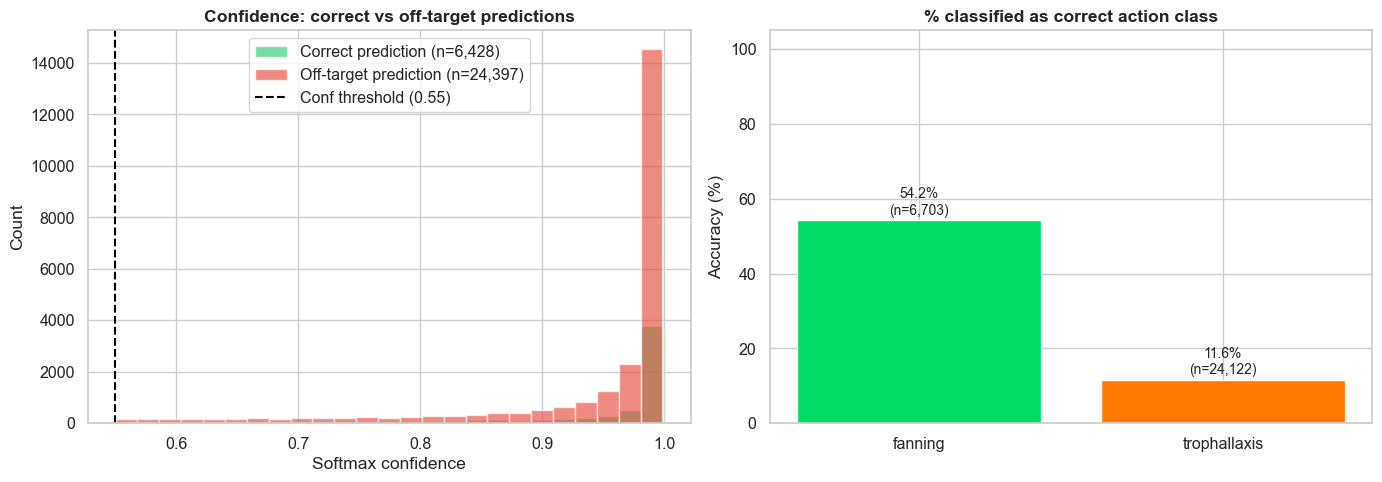

Saved: D:/Projects/Masters\ActionRecognition\graph_3_action_confidence.png


In [11]:
ar_classified = ar_df[ar_df['action'].isin(ACTION_CLASSES)].copy()
ar_classified['correct'] = ar_classified.apply(
    lambda r: r['action'] == r['dataset'], axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confidence histogram — correct vs incorrect predictions
for label, subset, color in [
    ('Correct prediction',   ar_classified[ar_classified['correct']],  '#2ecc71'),
    ('Off-target prediction', ar_classified[~ar_classified['correct']], '#e74c3c'),
]:
    if len(subset):
        axes[0].hist(subset['action_conf'], bins=25, alpha=0.65,
                     label=f'{label} (n={len(subset):,})', color=color)

axes[0].axvline(ACTION_CONF_TH, color='black', linestyle='--',
                label=f'Conf threshold ({ACTION_CONF_TH})')
axes[0].set_title('Confidence: correct vs off-target predictions', fontweight='bold')
axes[0].set_xlabel('Softmax confidence')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: per-dataset accuracy (% of classified detections that are the correct class)
acc_rows = []
for ds in ['fanning', 'trophallaxis']:
    sub = ar_classified[ar_classified['dataset'] == ds]
    if len(sub) == 0:
        continue
    correct_pct = sub['correct'].mean() * 100
    acc_rows.append({'dataset': ds, 'accuracy_pct': correct_pct, 'n': len(sub)})

acc_df = pd.DataFrame(acc_rows)
bar_c  = [DATASET_COLORS.get(d, '#888') for d in acc_df['dataset']]
bars   = axes[1].bar(acc_df['dataset'], acc_df['accuracy_pct'], color=bar_c, edgecolor='white')
for bar, row in zip(bars, acc_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, row.accuracy_pct + 0.8,
                 f'{row.accuracy_pct:.1f}%\n(n={row.n:,})',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 105)
axes[1].set_title('% classified as correct action class', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
out3 = os.path.join(OUTPUT_DIR, 'graph_3_action_confidence.png')
plt.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}')

### Figure 4 — Track Lifetime Distribution

How many frames does ByteTracker maintain each bee's identity?  
Longer tracks = more stable tracking = better temporal feature buffers.

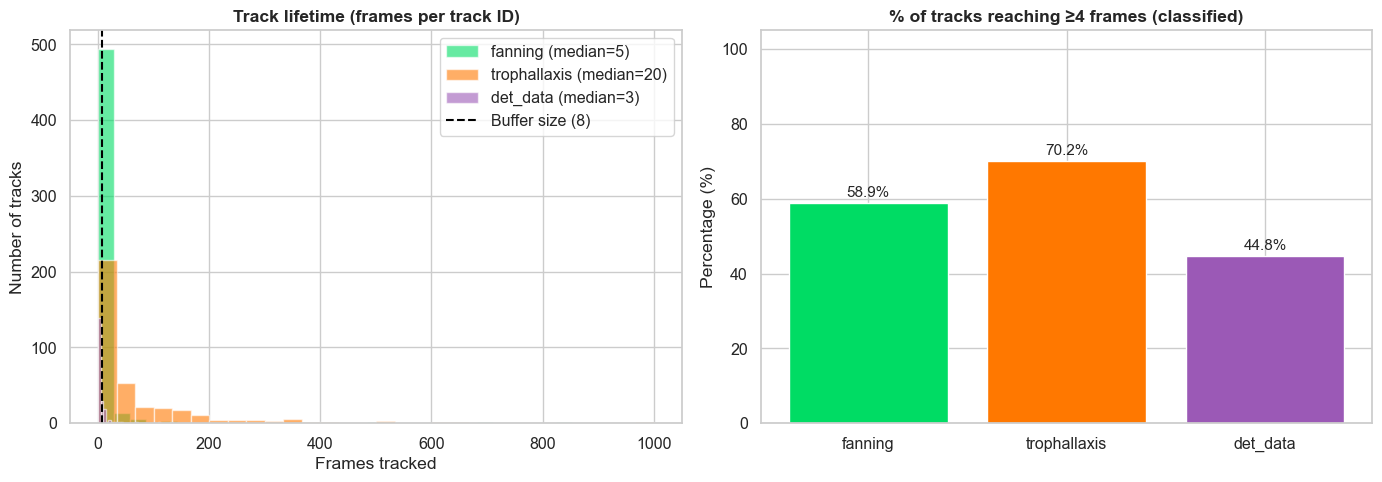

Saved: D:/Projects/Masters\ActionRecognition\graph_4_track_lifetime.png


In [12]:
track_lengths = (
    df.groupby(['dataset', 'track_id'])['frame_idx']
    .count()
    .reset_index()
    .rename(columns={'frame_idx': 'track_length'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram per dataset
order = [d for d in ['fanning', 'trophallaxis', 'det_data'] if d in track_lengths['dataset'].unique()]
for ds in order:
    sub = track_lengths[track_lengths['dataset'] == ds]['track_length']
    axes[0].hist(sub, bins=30, alpha=0.6,
                 label=f'{ds} (median={sub.median():.0f})',
                 color=DATASET_COLORS.get(ds, '#888888'))
axes[0].axvline(BUFFER_SIZE, color='black', linestyle='--',
                label=f'Buffer size ({BUFFER_SIZE})')
axes[0].set_title('Track lifetime (frames per track ID)', fontweight='bold')
axes[0].set_xlabel('Frames tracked')
axes[0].set_ylabel('Number of tracks')
axes[0].legend()

# Right: % of tracks that reach at least MIN_BUFFER frames
pct_rows = []
for ds in order:
    sub = track_lengths[track_lengths['dataset'] == ds]['track_length']
    pct = (sub >= MIN_BUFFER).mean() * 100
    pct_rows.append({'dataset': ds, 'pct_classified': pct})

pct_df = pd.DataFrame(pct_rows)
bars   = axes[1].bar(
    pct_df['dataset'], pct_df['pct_classified'],
    color=[DATASET_COLORS.get(d, '#888') for d in pct_df['dataset']],
    edgecolor='white'
)
for bar, row in zip(bars, pct_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, row.pct_classified + 0.8,
                 f'{row.pct_classified:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_ylim(0, 105)
axes[1].set_title(f'% of tracks reaching ≥{MIN_BUFFER} frames (classified)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')

plt.tight_layout()
out4 = os.path.join(OUTPUT_DIR, 'graph_4_track_lifetime.png')
plt.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out4}')

## Summary

In [13]:
print('Figures saved:')
for f in ['graph_1_confusion.png', 'graph_2_det_confidence.png',
          'graph_3_action_confidence.png', 'graph_4_track_lifetime.png']:
    path = os.path.join(OUTPUT_DIR, f)
    exists = '✓' if os.path.exists(path) else '✗'
    print(f'  {exists}  {path}')

print()
print('Detection summary:')
print(df.groupby('dataset')[['det_conf']].agg(['mean', 'median', 'count']).round(3).to_string())

print()
print('Action prediction breakdown:')
print(df.groupby(['dataset', 'action']).size().unstack(fill_value=0).to_string())

Figures saved:
  ✓  D:/Projects/Masters\ActionRecognition\graph_1_confusion.png
  ✓  D:/Projects/Masters\ActionRecognition\graph_2_det_confidence.png
  ✓  D:/Projects/Masters\ActionRecognition\graph_3_action_confidence.png
  ✓  D:/Projects/Masters\ActionRecognition\graph_4_track_lifetime.png

Detection summary:
             det_conf              
                 mean median  count
dataset                            
det_data        0.908  0.917   1330
fanning         0.907  0.924   8212
trophallaxis    0.906  0.916  25659

Action prediction breakdown:
action        buffering  fanning  neutral  trophallaxis  uncertain
dataset                                                           
det_data            466      261      580             0         23
fanning            1352     3632     2892           179        157
trophallaxis        977    13106     8220          2796        560
